###  Question 1

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import math

#### Part a

I used the paper mentioned in order to reproduce Figure 2. I used the Louvain method to detect the partition with the highest modularity, because I was not sure how to use Equation 1 and simulated annealing, as was mentioned in the paper.

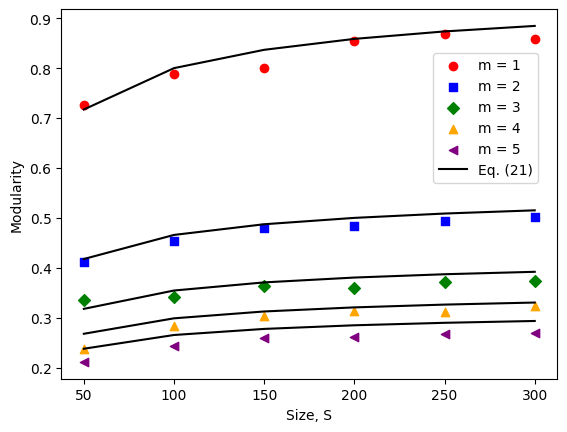

In [3]:

# This is based on Equation 21 in the paper, and is used to produce the lines on the figure
def eq21(m, S, a=0.165):
  line = []
  for v in S:
    res = (a + ((1-a) / m)) * (1 - (2 / math.sqrt(v)))
    line.append(res)
  return line

# Generate the graphs for the figure, and specify their colors and markers for plotting
def generate_graph_data():
  scale_free_graphs = {}

  for size in range(50, 301, 50):
    for m in range(1, 6):
      G = nx.barabasi_albert_graph(size, m)
      modularity = nx.community.modularity(G, nx.community.louvain_communities(G))
      scale_free_graphs[(size, m)] = modularity

  x = np.array(list(scale_free_graphs.keys()))[:, 0]
  ms = np.array(list(scale_free_graphs.keys()))[:, 1]
  y = np.array(list(scale_free_graphs.values()))

  markers =[]
  colors = []

  for m in ms:
      if m==1:
          markers.append('o')
          colors.append('red')
      elif m==2:
          markers.append('s')
          colors.append('blue')
      elif m==3:
          markers.append('D')
          colors.append('green')
      elif m==4:
          markers.append('^')
          colors.append('orange')
      else:
          markers.append('<')
          colors.append('purple')
  return x, ms, y, markers, colors


# Plot the figure
def plot_figure():
  x, ms, y, markers, colors = generate_graph_data()

  for i in range(len(x)):
    if i < 5:
      plt.scatter(x[i], y[i], c=colors[i], marker=markers[i], label=f'm = {ms[i]}')
    else:
      plt.scatter(x[i], y[i], c=colors[i], marker=markers[i])

  plt.xlabel('Size, S')
  plt.ylabel('Modularity')


  S=[50, 100, 150, 200, 250, 300]
  for i in range(1, 6):
    if i == 1:
      plt.plot(S, eq21(i, S), color="black", label='Eq. (21)')
    else:
      plt.plot(S, eq21(i, S), color="black")

  plt.legend(loc=(0.75, 0.53))

  plt.show()

plot_figure()

Comments on the result: the basis of modularity is that we would expect it to be very low in random graphs. This paper challenges that result, and shows that modularity is often a poor measure of partition quality, as random graphs can have high modularity for a number of reasons. In the paper, they describe this result as surprising, and conclude that scale-free networks can have high modularity due to "fluctuations in the establishment of links".

#### Part b

Note: in order to get graph-tool to work in Google Colab, I used this example: https://colab.research.google.com/github/count0/colab-gt/blob/master/colab-gt.ipynb

In [4]:
!wget https://downloads.skewed.de/skewed-keyring/skewed-keyring_1.0_all_$(lsb_release -s -c).deb
!dpkg -i skewed-keyring_1.0_all_$(lsb_release -s -c).deb
!echo "deb [signed-by=/usr/share/keyrings/skewed-keyring.gpg] https://downloads.skewed.de/apt $(lsb_release -s -c) main" > /etc/apt/sources.list.d/skewed.list
!apt-get update
!apt-get install python3-graph-tool python3-matplotlib python3-cairo

--2024-11-12 02:16:48--  https://downloads.skewed.de/skewed-keyring/skewed-keyring_1.0_all_jammy.deb
Resolving downloads.skewed.de (downloads.skewed.de)... 49.12.93.194
Connecting to downloads.skewed.de (downloads.skewed.de)|49.12.93.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23192 (23K) [application/x-debian-package]
Saving to: ‘skewed-keyring_1.0_all_jammy.deb’

skewed-keyring_1.0_ 100%[===================>]  22.65K   111KB/s    in 0.2s    

2024-11-12 02:16:49 (111 KB/s) - ‘skewed-keyring_1.0_all_jammy.deb’ saved [23192/23192]

Selecting previously unselected package skewed-keyring.
(Reading database ... 123624 files and directories currently installed.)
Preparing to unpack skewed-keyring_1.0_all_jammy.deb ...
Unpacking skewed-keyring (1.0) ...
Setting up skewed-keyring (1.0) ...
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRe

In [5]:
# Colab uses a Python install that deviates from the system's! Bad colab! We need some workarounds.
!apt purge python3-cairo
!apt install libcairo2-dev pkg-config python3-dev
!pip install --force-reinstall pycairo
!pip install zstandard

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following packages will be REMOVED:
  python3-cairo*
0 upgraded, 0 newly installed, 1 to remove and 54 not upgraded.
After this operation, 310 kB disk space will be freed.
(Reading database ... 132031 files and directories currently installed.)
Removing python3-cairo:amd64 (1.20.1-3build1) ...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-dev is already the newest version (3.10.6-1~22.04.1).
python3-dev set to manually installed.
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libblkid-dev libblkid1 libcairo-script-interpreter2 libffi-dev libglib2.0-dev libglib2.0-dev-bin
  libice-dev liblzo2-2 libmount-dev libmount1 libpixman-1-dev libselinux1-dev libsepol-dev
  lib

In [6]:
import graph_tool.all as gt

In [7]:
# get the polblogs dataset and extract the largest connected component
polblogs_graph = gt.collection.ns["polblogs"]
polblogs_graph.set_directed(False) # turn the graph into an undirected graph, as the next step did not do that properly on its own
g = gt.extract_largest_component(polblogs_graph, directed=False)

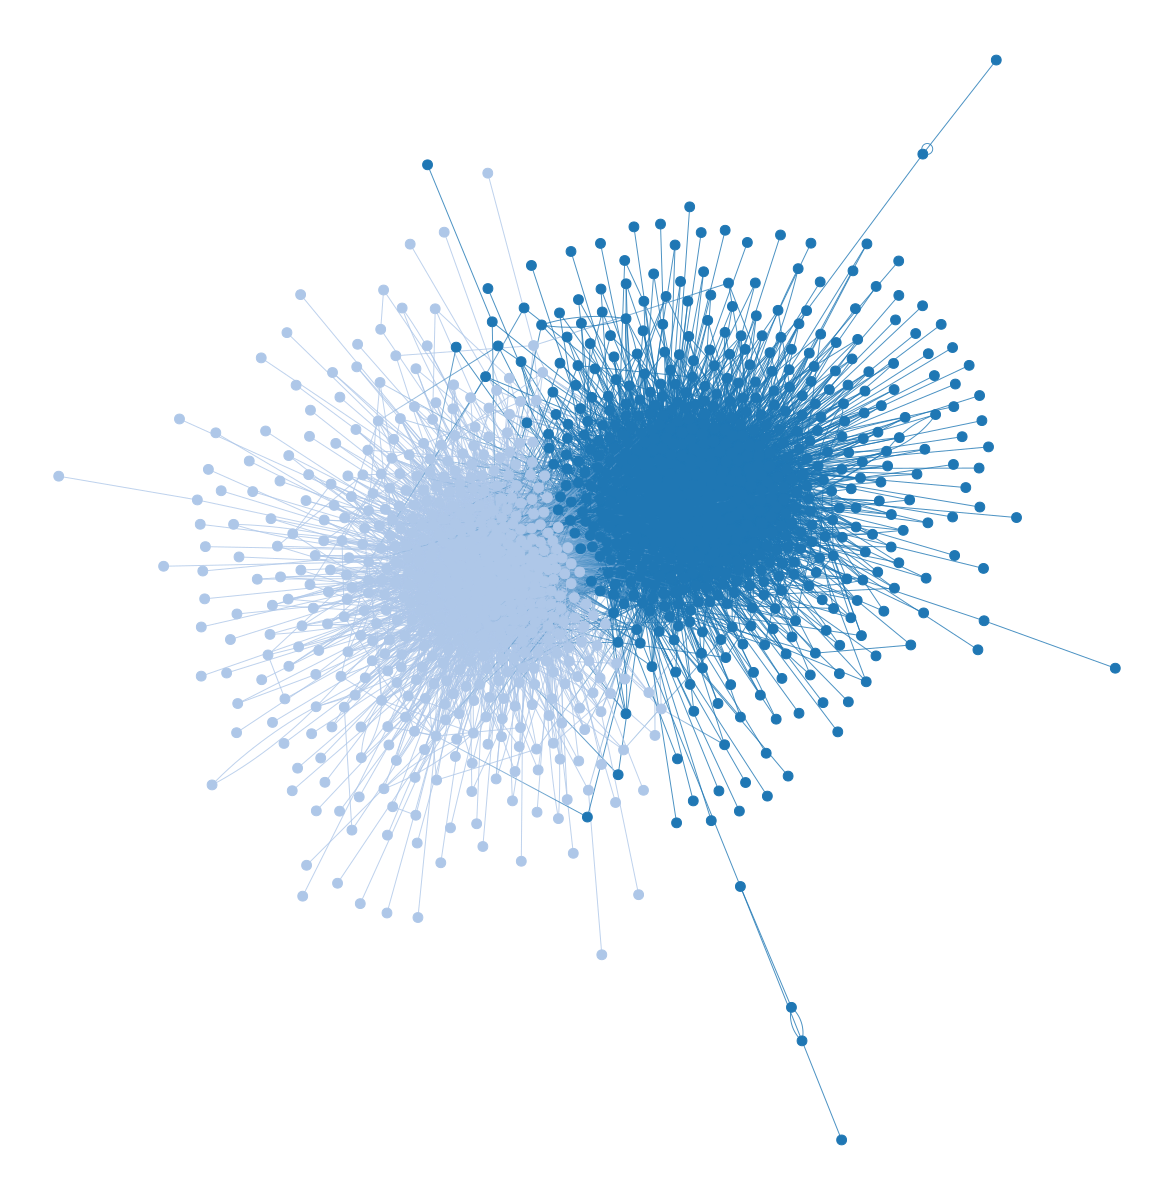

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7b811dc38b50, at 0x7b815c586650>

In [106]:
# degree corrected stochastic model
state_deg_corr = gt.minimize_blockmodel_dl(g, state=gt.BlockState, state_args={'B' : 2}, multilevel_mcmc_args={'B_min' : 2, 'B_max' : 2})
state_deg_corr.draw()

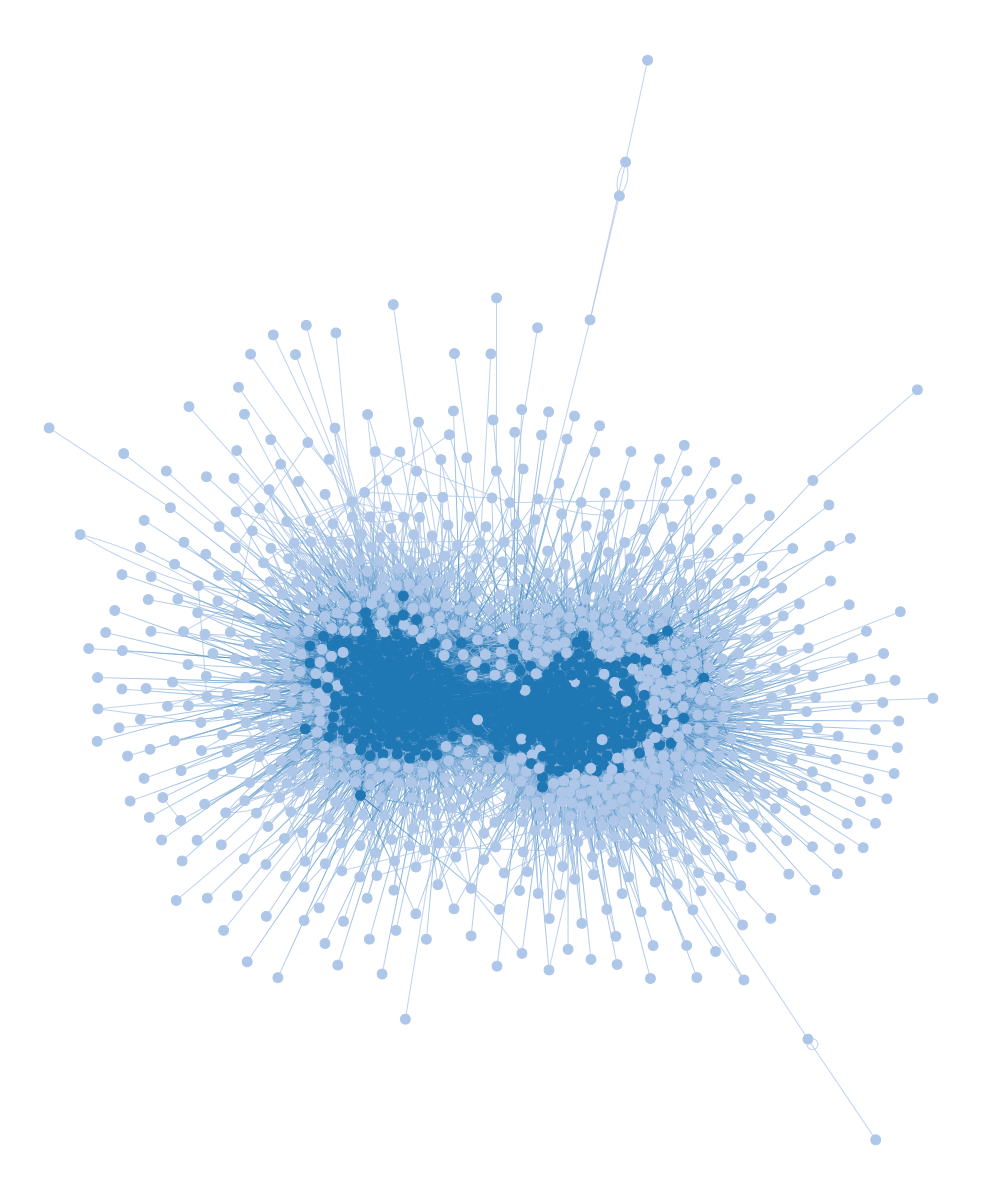

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7b811dc38b50, at 0x7b815c584e50>

In [108]:
# non-degree corrected stochastic model
state_non_deg_corr = gt.minimize_blockmodel_dl(g, state=gt.BlockState, state_args={'B' : 2, 'deg_corr' : False}, multilevel_mcmc_args={'B_min' : 2, 'B_max' : 2})
state_non_deg_corr.draw()

#### Part c

i)

In [105]:
# description length of degree-corrected model
print("description length (degree-corrected): " + str(state_deg_corr.entropy()))

# description length of non-degree-corrected model
print("description length (non-degree-corrected): " + str(state_non_deg_corr.entropy()))


description length (degree-corrected): 58099.298327208155
description length (non-degree-corrected): 72415.29227299464


ii)

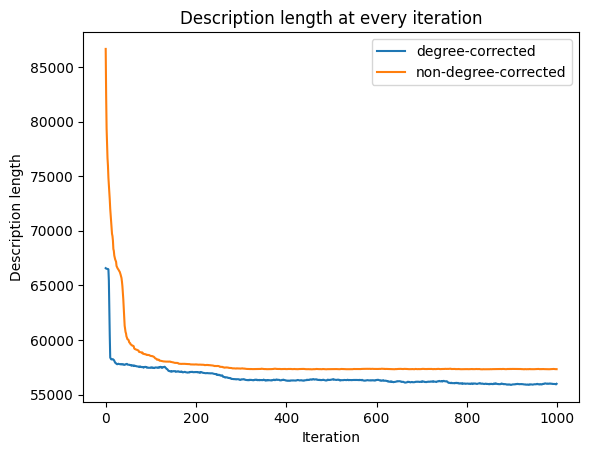

In [10]:
state_deg_corr = gt.BlockState(g, B=2, deg_corr=True)
state_non_deg_corr = gt.BlockState(g, B=2, deg_corr=False)

desc_lengths_deg_corr = []
desc_lengths_non_deg_corr = []

for _ in range(1000):
  state_deg_corr.mcmc_sweep(niter=1)
  state_non_deg_corr.mcmc_sweep(niter=1)

  desc_lengths_deg_corr.append(state_deg_corr.entropy())
  desc_lengths_non_deg_corr.append(state_non_deg_corr.entropy())

# plot the description lengths at every step for both models in a single plot
plt.plot(desc_lengths_deg_corr, label="degree-corrected")
plt.plot(desc_lengths_non_deg_corr, label="non-degree-corrected")
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Description length')
plt.title('Description length at every iteration')
plt.show()


Comments: we can see from the graph that the degree-corrected version of the model always yields a lower description length, which is preferred.

#### Part d

The intuition behind degree correction is one that corrects a poor underlying assumption - that nodes that have around the same number of edges should belong to the same group. However, heterogeneous degrees are common among communities, meaning that some nodes are highly connected and some are not. Non-degree-corrected versions of the model will prefer to group nodes that are highly connected. The corrected version gives each node an "expected degree", which allows for more focus on where the edges are going, and not just the value of the degree.


### Question 4

I used ChatGPT for help with some of the code for this question - I have inserted comments above portions of code that were assisted by ChatGPT.

#### Part a

T-SNE is a dimensionality reduction algorithm. This means that it converts high-dimensional data into a lower dimension (usually 2D or 3D). This is useful, because data of really high dimensionality is not easy to visualize or understand. T-SNE is especially useful for non-linear data, and outperforms other algorithms (PCA, for example) in that regard. Its main drawbacks are that it can be really slow, as it has a high time complexity, and it is nondeterministic, meaning that it can return different results on the same data.

#### Parts b and c

This code is adapted from the code we saw in class. I also used some suggestions from ChatGPT for making it better (which I'm not convinced actually did anything).

In [2]:
from torch.nn import Linear
import torch

In [3]:
!pip install torch-geometric
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import CitationFull

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


cpu
Epoch: 000, Loss: 2.1876, Accuracy: 0.2116


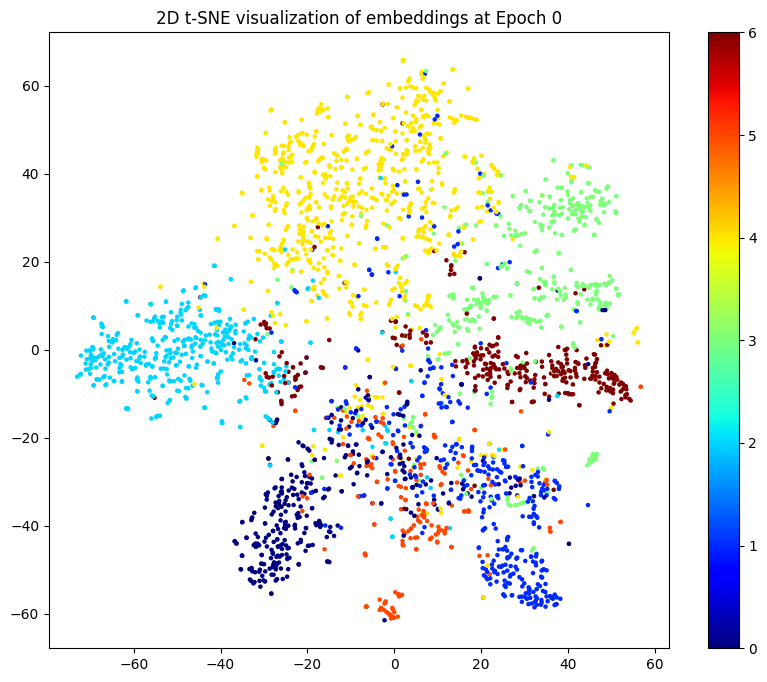

Epoch: 001, Loss: 1.3302, Accuracy: 0.6303
Epoch: 002, Loss: 1.1117, Accuracy: 0.7973
Epoch: 003, Loss: 0.9817, Accuracy: 0.8263
Epoch: 004, Loss: 0.8722, Accuracy: 0.8419
Epoch: 005, Loss: 0.7891, Accuracy: 0.8441
Epoch: 006, Loss: 0.7002, Accuracy: 0.8508
Epoch: 007, Loss: 0.6216, Accuracy: 0.8530
Epoch: 008, Loss: 0.5641, Accuracy: 0.8552
Epoch: 009, Loss: 0.5195, Accuracy: 0.8575
Epoch: 010, Loss: 0.4803, Accuracy: 0.8731


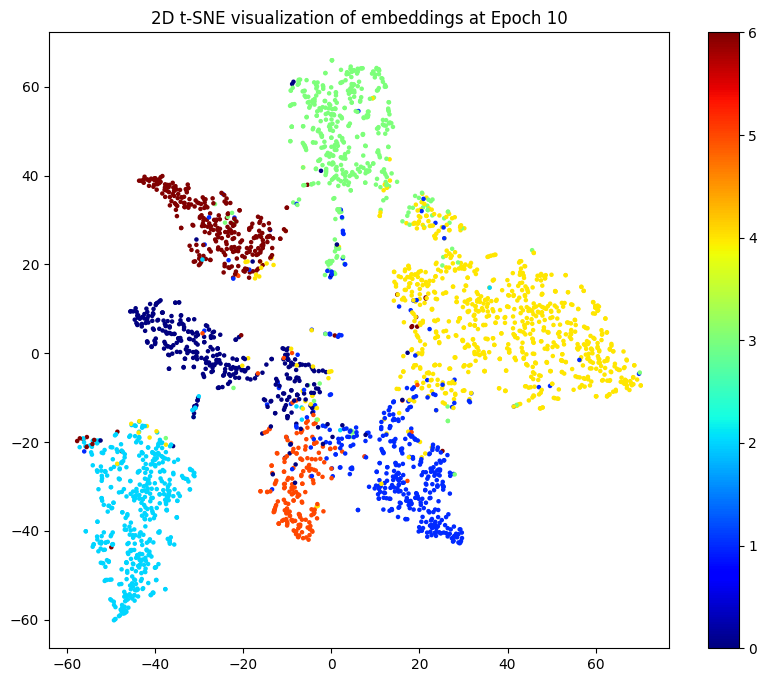

Epoch: 011, Loss: 0.4423, Accuracy: 0.8686
Epoch: 012, Loss: 0.4191, Accuracy: 0.8686
Epoch: 013, Loss: 0.3879, Accuracy: 0.8686
Epoch: 014, Loss: 0.3648, Accuracy: 0.8708
Epoch: 015, Loss: 0.3415, Accuracy: 0.8708
Epoch: 016, Loss: 0.3336, Accuracy: 0.8708
Epoch: 017, Loss: 0.3011, Accuracy: 0.8686
Epoch: 018, Loss: 0.2854, Accuracy: 0.8686
Epoch: 019, Loss: 0.2657, Accuracy: 0.8708
Epoch: 020, Loss: 0.2673, Accuracy: 0.8731


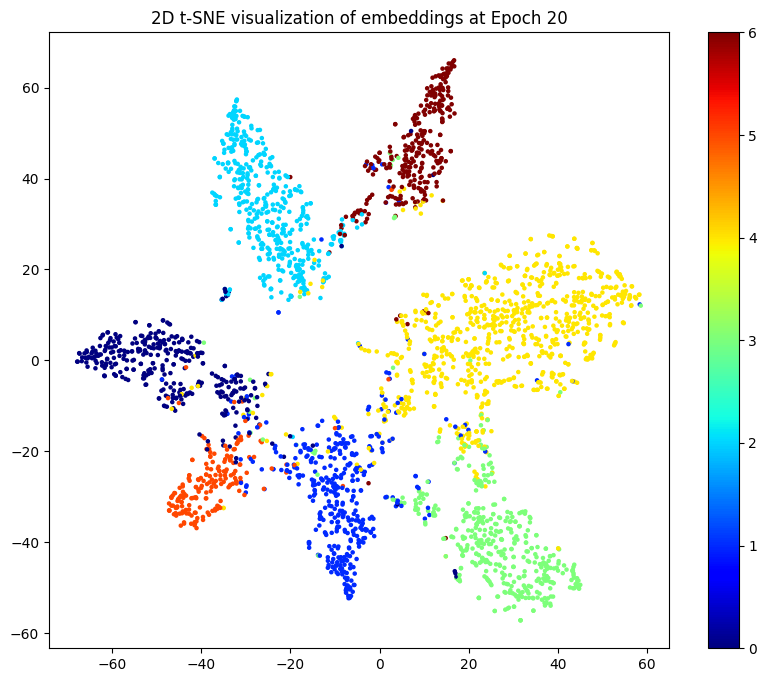

Epoch: 021, Loss: 0.2471, Accuracy: 0.8753
Epoch: 022, Loss: 0.2475, Accuracy: 0.8775
Epoch: 023, Loss: 0.2341, Accuracy: 0.8775
Epoch: 024, Loss: 0.2210, Accuracy: 0.8797
Epoch: 025, Loss: 0.2132, Accuracy: 0.8775
Epoch: 026, Loss: 0.2005, Accuracy: 0.8731
Epoch: 027, Loss: 0.1931, Accuracy: 0.8708
Epoch: 028, Loss: 0.1813, Accuracy: 0.8686
Epoch: 029, Loss: 0.1782, Accuracy: 0.8708
Epoch: 030, Loss: 0.1678, Accuracy: 0.8686


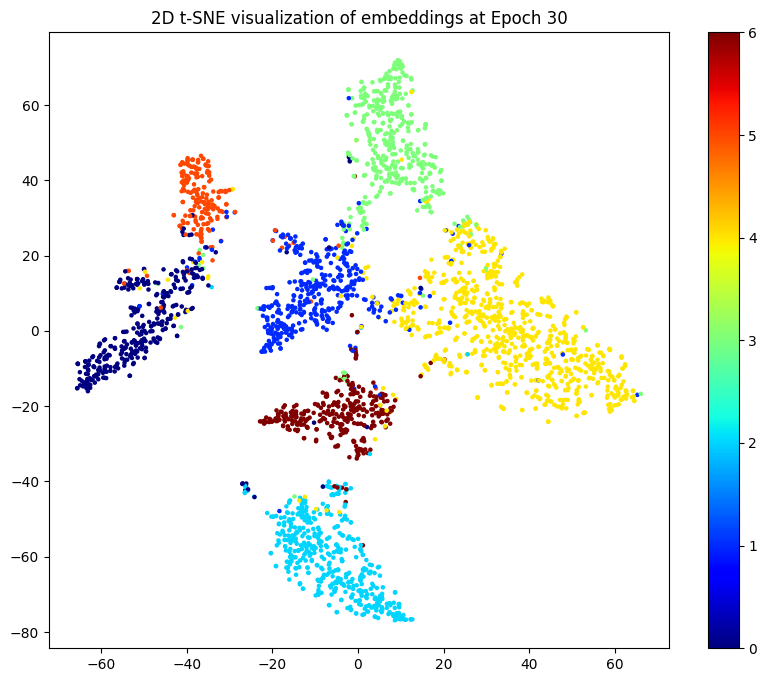

Epoch: 031, Loss: 0.1628, Accuracy: 0.8686
Epoch: 032, Loss: 0.1469, Accuracy: 0.8686
Epoch: 033, Loss: 0.1521, Accuracy: 0.8708
Epoch: 034, Loss: 0.1430, Accuracy: 0.8731
Epoch: 035, Loss: 0.1420, Accuracy: 0.8708
Epoch: 036, Loss: 0.1254, Accuracy: 0.8686
Epoch: 037, Loss: 0.1255, Accuracy: 0.8686
Epoch: 038, Loss: 0.1287, Accuracy: 0.8686
Epoch: 039, Loss: 0.1187, Accuracy: 0.8575
Epoch: 040, Loss: 0.1168, Accuracy: 0.8575


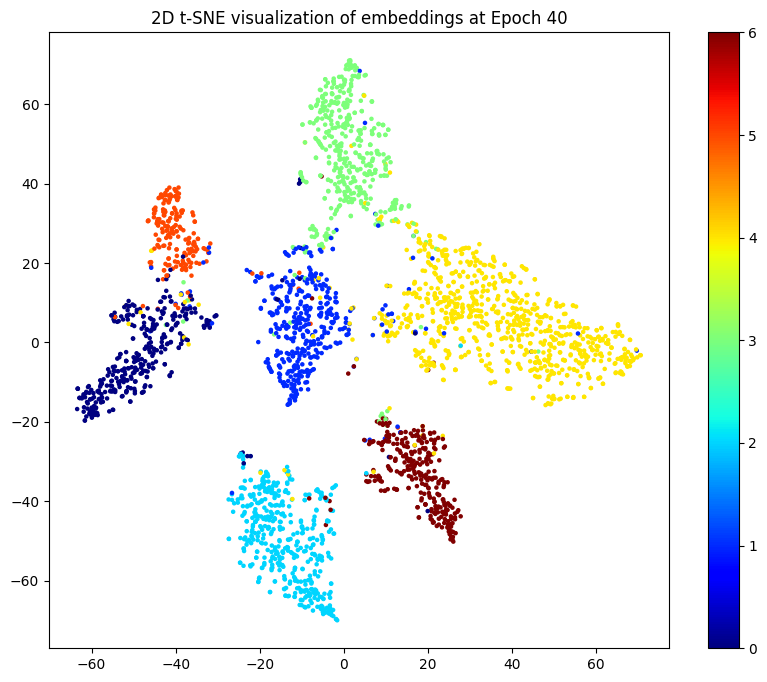

Epoch: 041, Loss: 0.1131, Accuracy: 0.8597
Epoch: 042, Loss: 0.1134, Accuracy: 0.8597
Epoch: 043, Loss: 0.1014, Accuracy: 0.8575
Epoch: 044, Loss: 0.1105, Accuracy: 0.8597
Epoch: 045, Loss: 0.1009, Accuracy: 0.8575
Epoch: 046, Loss: 0.0947, Accuracy: 0.8552
Epoch: 047, Loss: 0.1043, Accuracy: 0.8552
Epoch: 048, Loss: 0.1049, Accuracy: 0.8575
Epoch: 049, Loss: 0.0888, Accuracy: 0.8552
Epoch: 050, Loss: 0.0909, Accuracy: 0.8508


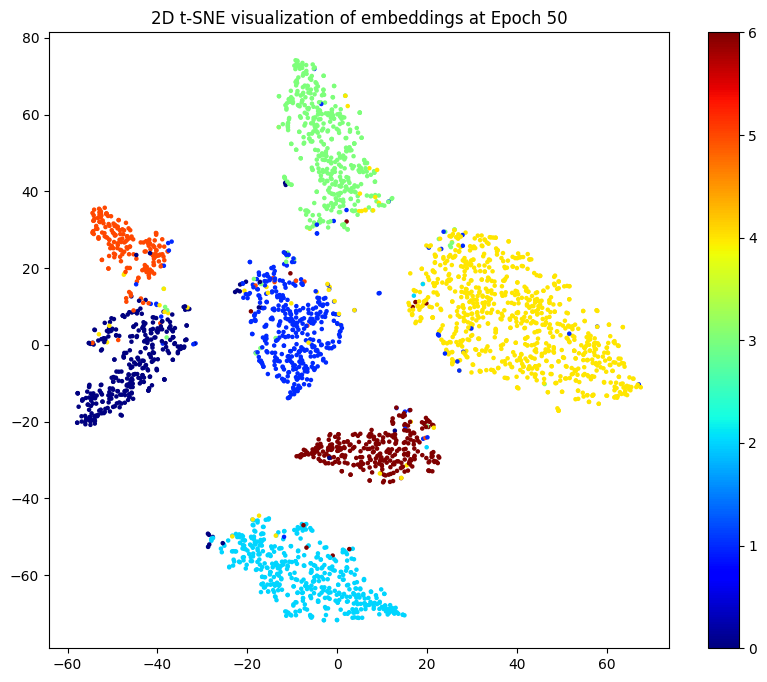

Epoch: 051, Loss: 0.0953, Accuracy: 0.8552
Epoch: 052, Loss: 0.0797, Accuracy: 0.8597
Epoch: 053, Loss: 0.0877, Accuracy: 0.8597
Epoch: 054, Loss: 0.0796, Accuracy: 0.8686
Epoch: 055, Loss: 0.0717, Accuracy: 0.8686
Epoch: 056, Loss: 0.0738, Accuracy: 0.8664
Epoch: 057, Loss: 0.0678, Accuracy: 0.8597
Epoch: 058, Loss: 0.0701, Accuracy: 0.8619
Epoch: 059, Loss: 0.0720, Accuracy: 0.8530
Epoch: 060, Loss: 0.0838, Accuracy: 0.8530


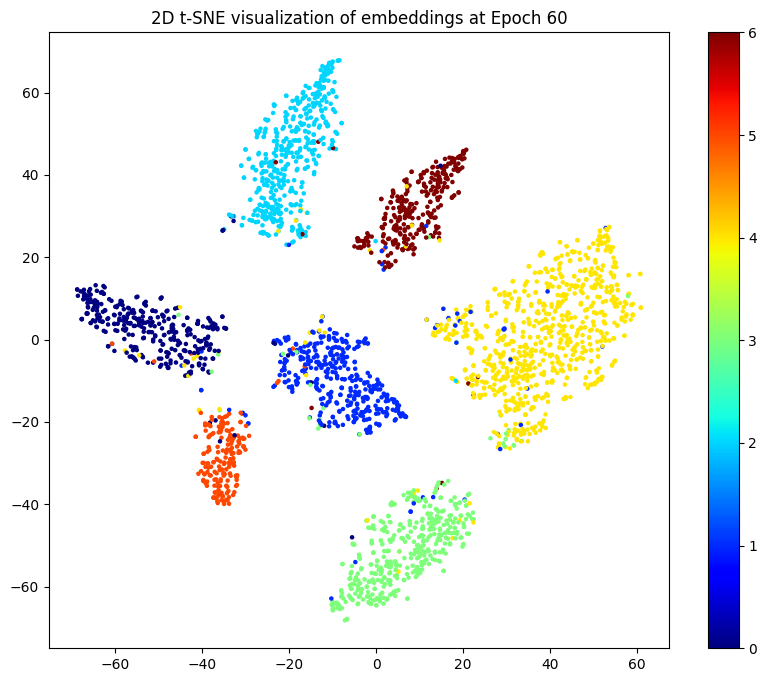

Epoch: 061, Loss: 0.0780, Accuracy: 0.8575
Epoch: 062, Loss: 0.0748, Accuracy: 0.8575
Epoch: 063, Loss: 0.0755, Accuracy: 0.8552
Epoch: 064, Loss: 0.0544, Accuracy: 0.8597
Epoch: 065, Loss: 0.0526, Accuracy: 0.8664
Epoch: 066, Loss: 0.0623, Accuracy: 0.8641
Epoch: 067, Loss: 0.0640, Accuracy: 0.8641
Epoch: 068, Loss: 0.0645, Accuracy: 0.8597
Epoch: 069, Loss: 0.0536, Accuracy: 0.8619
Epoch: 070, Loss: 0.0522, Accuracy: 0.8552


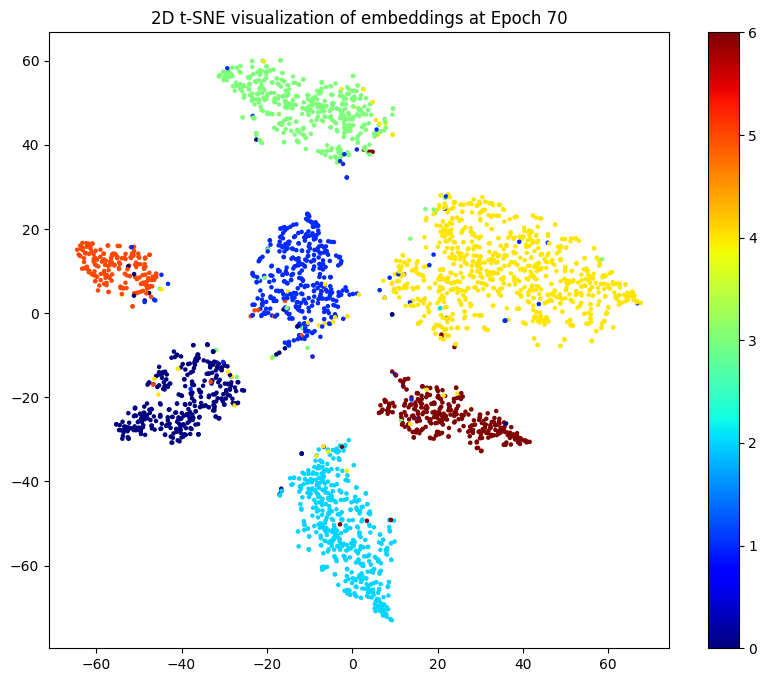

Epoch: 071, Loss: 0.0612, Accuracy: 0.8530
Epoch: 072, Loss: 0.0621, Accuracy: 0.8552
Epoch: 073, Loss: 0.0566, Accuracy: 0.8441
Epoch: 074, Loss: 0.0537, Accuracy: 0.8396
Epoch: 075, Loss: 0.0630, Accuracy: 0.8486
Epoch: 076, Loss: 0.0661, Accuracy: 0.8463
Epoch: 077, Loss: 0.0702, Accuracy: 0.8419
Epoch: 078, Loss: 0.0684, Accuracy: 0.8486
Epoch: 079, Loss: 0.0494, Accuracy: 0.8508
Epoch: 080, Loss: 0.0626, Accuracy: 0.8463


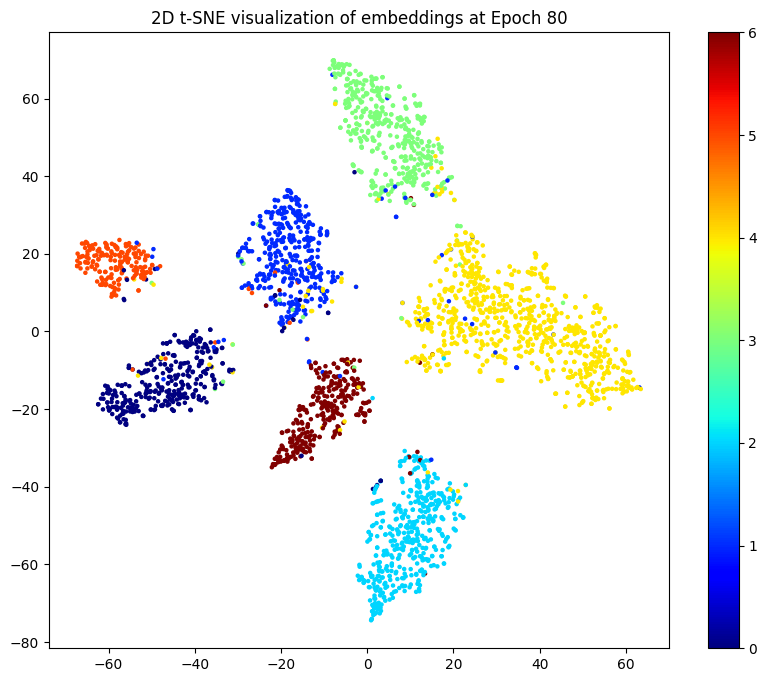

Epoch: 081, Loss: 0.0588, Accuracy: 0.8508
Epoch: 082, Loss: 0.0643, Accuracy: 0.8552
Epoch: 083, Loss: 0.0599, Accuracy: 0.8641
Epoch: 084, Loss: 0.0607, Accuracy: 0.8686
Epoch: 085, Loss: 0.0569, Accuracy: 0.8664
Epoch: 086, Loss: 0.0470, Accuracy: 0.8619
Epoch: 087, Loss: 0.0499, Accuracy: 0.8597
Epoch: 088, Loss: 0.0594, Accuracy: 0.8552
Epoch: 089, Loss: 0.0587, Accuracy: 0.8552
Epoch: 090, Loss: 0.0520, Accuracy: 0.8530


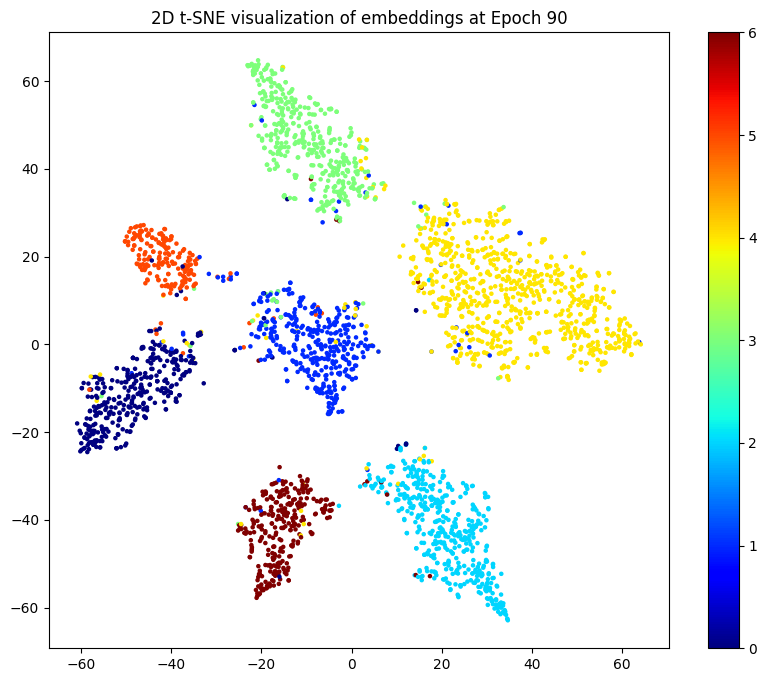

Epoch: 091, Loss: 0.0653, Accuracy: 0.8552
Epoch: 092, Loss: 0.0675, Accuracy: 0.8597
Epoch: 093, Loss: 0.0614, Accuracy: 0.8619
Epoch: 094, Loss: 0.0567, Accuracy: 0.8597
Epoch: 095, Loss: 0.0461, Accuracy: 0.8530
Epoch: 096, Loss: 0.0512, Accuracy: 0.8508
Epoch: 097, Loss: 0.0547, Accuracy: 0.8463
Epoch: 098, Loss: 0.0595, Accuracy: 0.8486
Epoch: 099, Loss: 0.0471, Accuracy: 0.8508


In [27]:
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import RandomNodeSplit
from torch_geometric.datasets import CitationFull
from sklearn.manifold import TSNE

# Storage for embeddings across epochs
tsne_embeddings = []
epochs = []

# This function both:
  # plots the data every ten epochs during training
  # saves the data every ten epochs (to be used later in the animation)
# ChatGPT helped me with this code
def plot_and_save_embeddings(epoch):
    model.eval()
    with torch.no_grad():
        embeddings, _ = model(batch.x.to(device), batch.edge_index.to(device))  # Get embeddings from the model
    embeddings = embeddings.cpu()

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    tsne_embeddings.append(embeddings_2d)
    epochs.append(epoch)
    # Plot embeddings
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=data.y.cpu(), cmap="jet", s=5)
    plt.colorbar()
    plt.title(f"2D t-SNE visualization of embeddings at Epoch {epoch}")
    plt.show()

# get the dataset
dataset = CitationFull(root='./', name='Cora_ML')
data = dataset.data

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn1 = GCNConv(dataset.num_features, 64)
        self.bn1 = torch.nn.BatchNorm1d(64)
        self.gcn2 = GCNConv(64, 32)
        self.bn2 = torch.nn.BatchNorm1d(32)
        self.out = Linear(32, dataset.num_classes)
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        h1 = self.dropout(self.bn1(self.gcn1(x, edge_index).relu()))
        h2 = self.dropout(self.bn2(self.gcn2(h1, edge_index).relu()))
        z = self.out(h2)
        return h2, z

splits = RandomNodeSplit(split='train_rest', num_val=0.15, num_test=0.15)(dataset.data)

model = GCN()
model.to(device)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
loader = DataLoader(dataset)

for epoch in range(0, 100):
    model.train()
    total_loss = 0
    tot_accuracy = 0
    for batch in loader:
        optimizer.zero_grad()
        h2, z = model(batch.x.to(device), batch.edge_index.to(device))
        loss = criterion(z[splits.train_mask], batch.y.to(device)[splits.train_mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    model.eval()
    val_h, val_z = model(dataset.x.to(device), dataset.edge_index.to(device))
    val_z = val_z[splits.val_mask]
    ans = val_z.argmax(dim=1)
    ys = batch.y.to(device)[splits.val_mask]
    tot_accuracy += torch.mean(torch.eq(ans, ys).float())
    loss = total_loss / len(loader)
    accuracy = tot_accuracy / len(loader)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')
    if epoch % 10 == 0:
      plot_and_save_embeddings(epoch)

Comments on how my embeddings change over time: The embeddings change very rapidly in the first few epochs, when loss is high and there is much obvious data to be learned. They quickly flatten out and remain more or less the same for the rest of training. This could be due to the small size of the dataset, or a weakness in the model.

#### Part d

I used the documentation referenced in the assignment and help from ChatGPT to produce this animation.

In [47]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.ioff()

# Animation
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(tsne_embeddings[0][:, 0], tsne_embeddings[0][:, 1], c=data.y.cpu(), s=5, cmap="jet")
plt.colorbar(scatter, ax=ax)
title = ax.text(0.5, 1.05, "", ha="center", va="center", transform=ax.transAxes, fontsize="large")

def animate(i):
    scatter.set_offsets(tsne_embeddings[i])  # Update points with t-SNE embeddings
    title.set_text(f"Epoch {epochs[i]}")
    return scatter, title

# Create animation
ani = FuncAnimation(fig=fig, func=animate, frames=len(tsne_embeddings), interval=500, blit=True)
plt.title("Evolution of Cora ML Node Embeddings Over Epochs")

HTML(ani.to_jshtml())

Comments on the animation: This animation allows us to see the rapid shift that the embeddings undergo. It is useful for visualizing the fact that sometimes training for more epochs does not necessarily yield better results. It also allows us to eyeball the embeddings in a way that makes sense.